In [1]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.vti import VTIWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO, PATH_DATA_DSUB
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"


In [2]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = 50.0
dataset.resample_on()

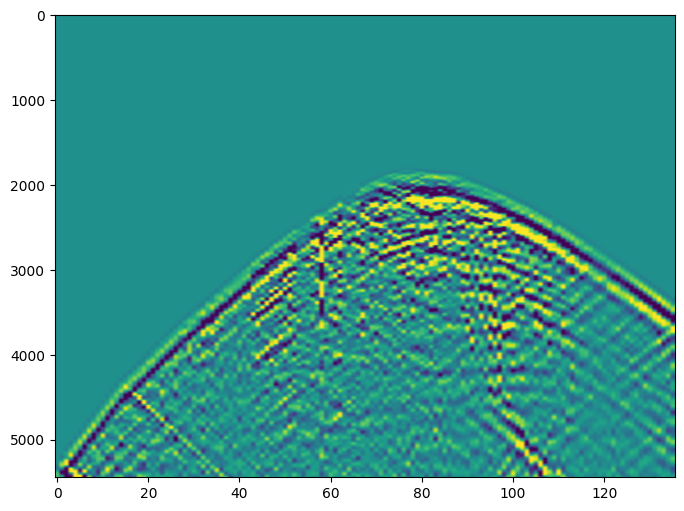

In [3]:
d_obs = dataset[80][0]
plt.imshow(d_obs.T, aspect='auto', vmin=-5, vmax=5)

In [4]:
velmodel.vp.min()*1000/10/2000

np.float64(0.05581395348837209)

In [5]:
dataset.x_coords                                                

array([82. , 82. , 82. , ..., 80.1, 80.1, 80.1])

In [6]:
dataset.opposite_x

array([40.61, 40.6 , 40.61, ..., 41.26, 41.26, 41.26])

In [7]:
print(dataset.opposite_elev)

[  4.84   5.84   6.84 ... 160.83 161.83 162.83]


In [8]:
len(dataset)

128

In [9]:
d, a, b, c, f = dataset[52]
print(a, b, c, f)

81.49 53.88 [40.61 40.6  40.61 40.61 40.62 40.63 40.62 40.63 40.63 40.63 40.63 40.64
 40.63 40.64 40.64 40.64 40.64 40.64 40.65 40.66 40.66 40.67 40.68 40.69
 40.71 40.71 40.71 40.71 40.71 40.72 40.72 40.71 40.71 40.71 40.71 40.71
 40.72 40.73 40.74 40.75 40.78 40.78 40.78 40.79 40.8  40.8  40.8  40.8
 40.8  40.8  40.82 40.83 40.85 40.86 40.87 40.89 40.89 40.9  40.9  40.9
 40.9  40.93 40.91 40.91 40.93 40.96 40.97 40.97 40.97 40.97 41.   41.01
 41.01 41.01 41.03 41.04 41.04 41.04 41.04 41.04 41.05 41.08 41.08 41.08
 41.08 41.08 41.08 41.1  41.11 41.11 41.12 41.12 41.15 41.15 41.15 41.15
 41.15 41.15 41.16 41.16 41.16 41.18 41.18 41.18 41.18 41.19 41.19 41.19
 41.19 41.19 41.19 41.19 41.19 41.19 41.21 41.21 41.21 41.22 41.22 41.21
 41.19 41.21 41.22 41.22 41.22 41.23 41.23 41.23 41.23 41.23 41.23 41.23
 41.23 41.23 41.23 41.23] [  4.84   5.84   6.84   7.84   8.85   9.85  10.85  11.85  12.85  13.85
  14.85  15.85  16.85  17.85  18.85  19.85  20.85  21.85  22.85  23.85
  24.85  25.85  26.

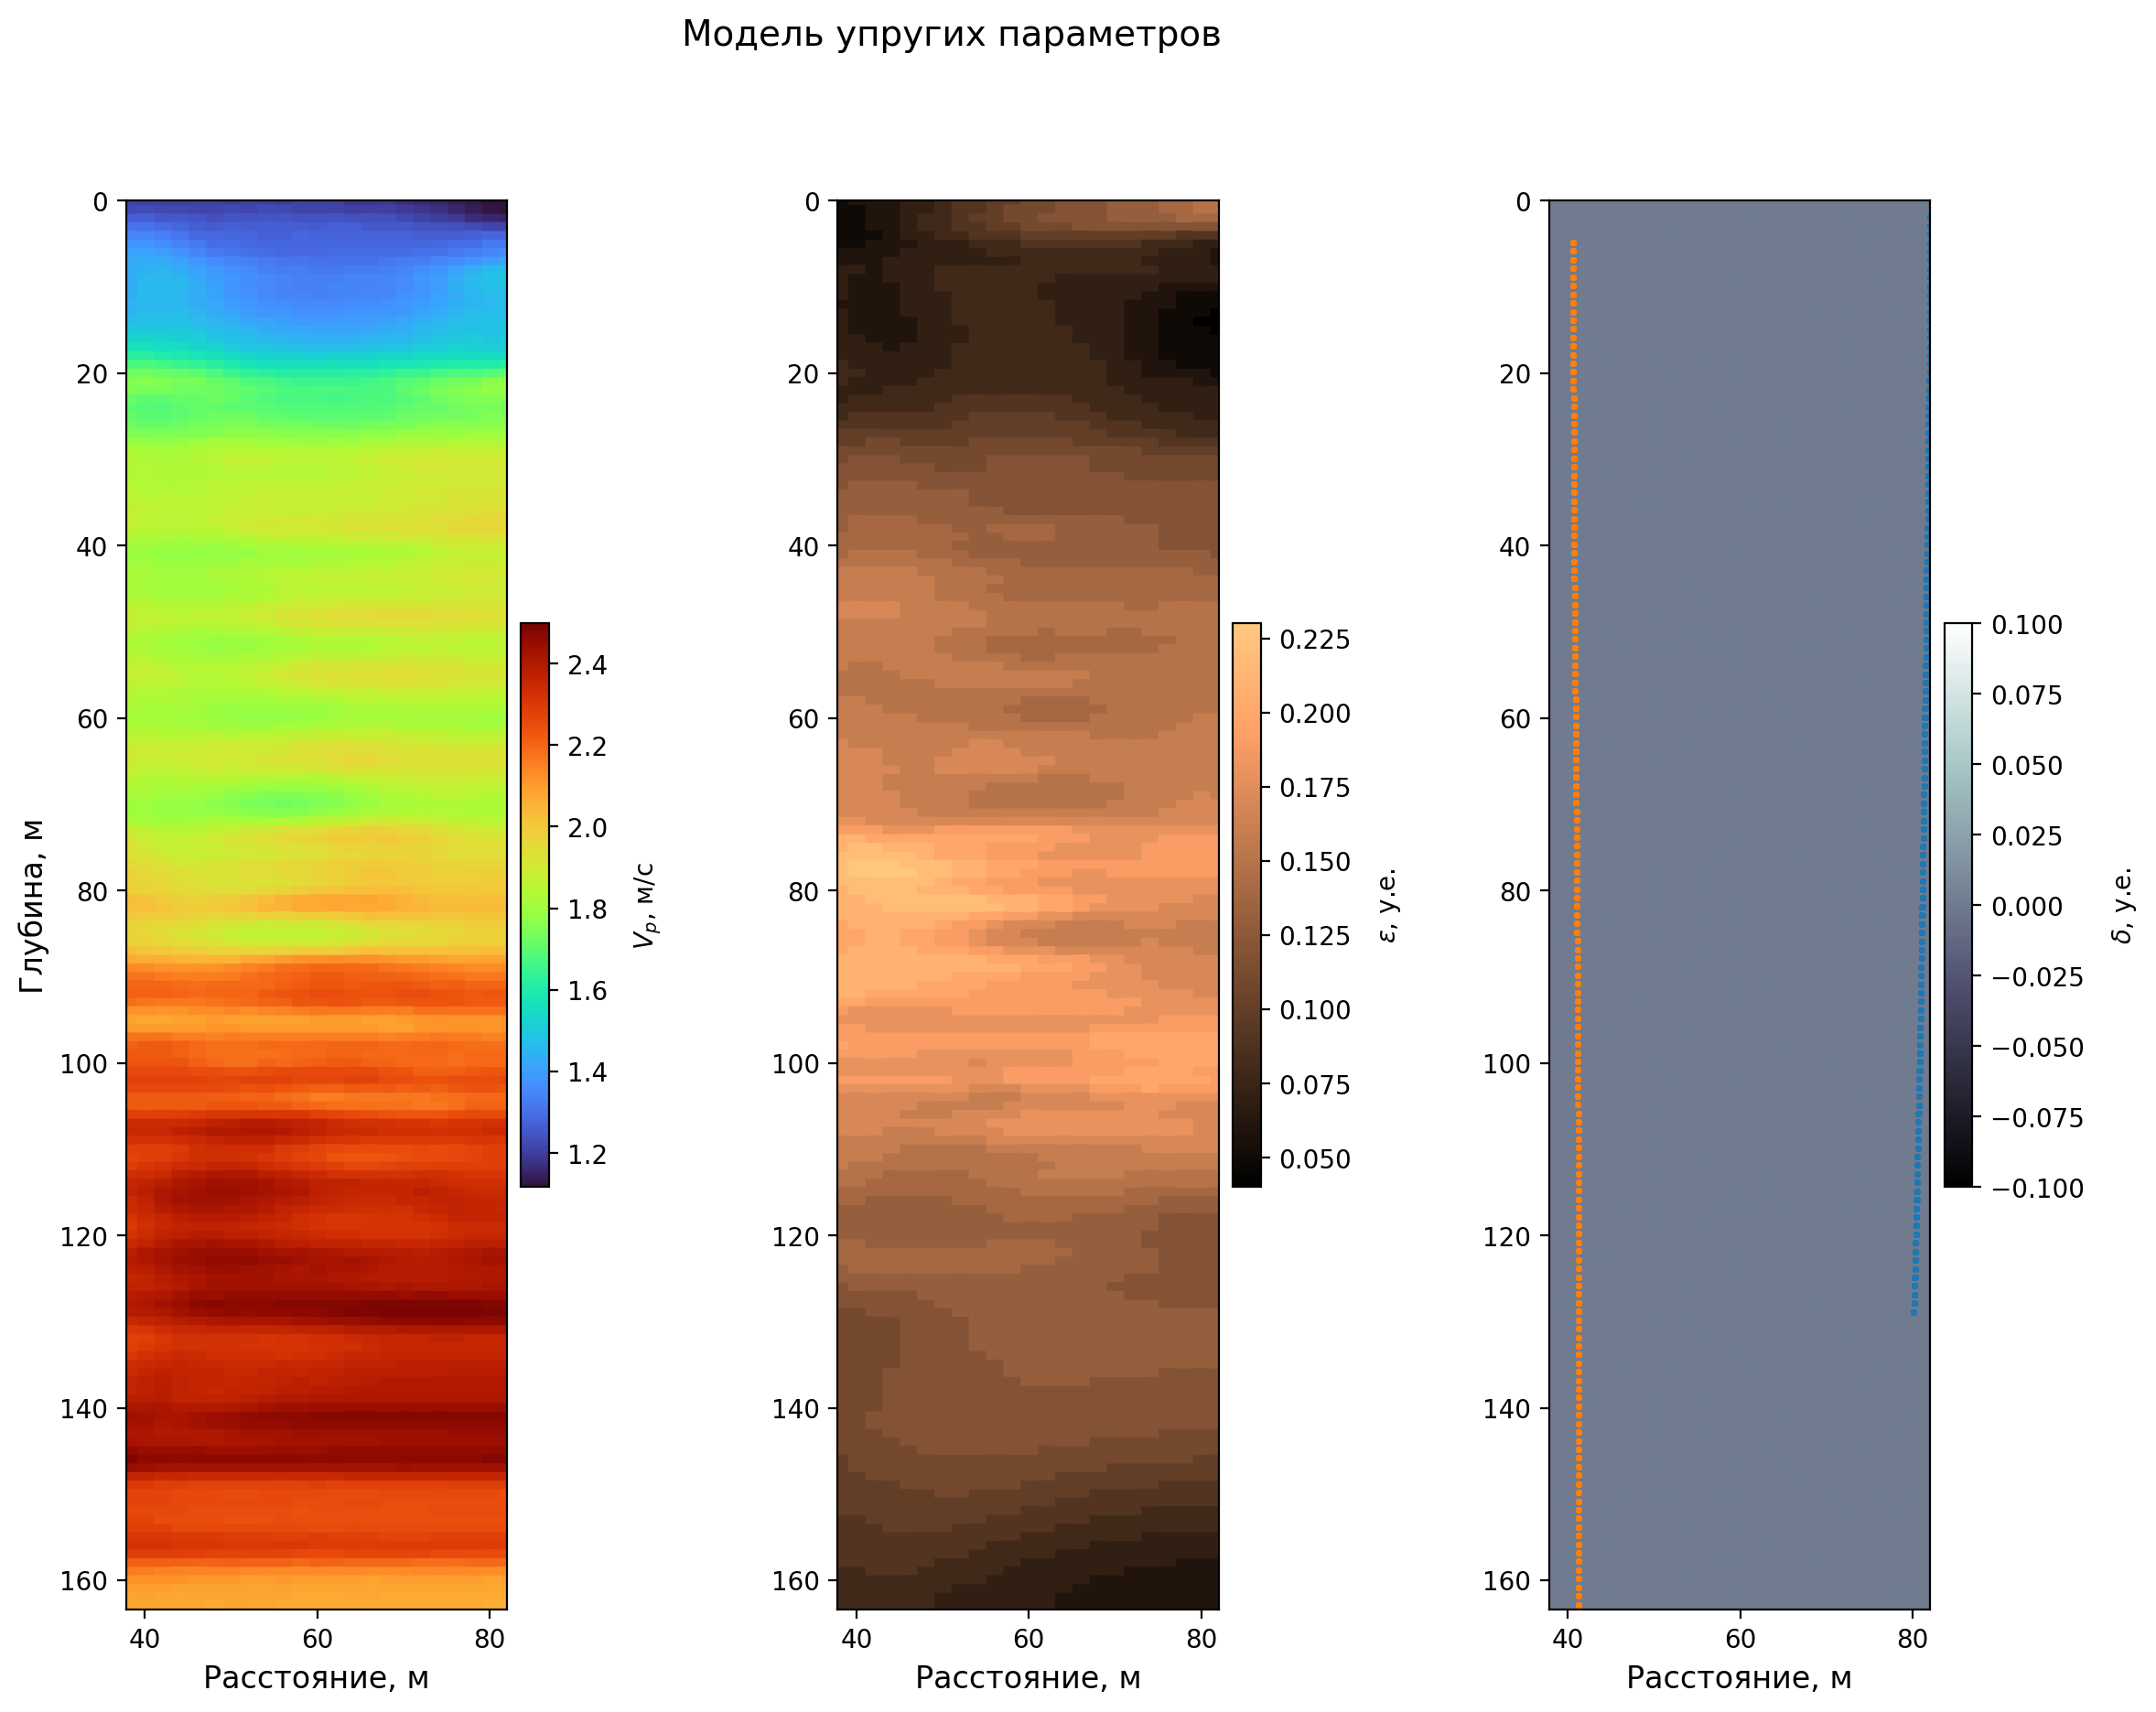

In [10]:
velmodel.plot_whole(show=False)
# plt.gcf().set_figheight(6)
# plt.gcf().set_figwidth(8)
plt.gca().scatter(dataset.x_coords, dataset.elevations, s=2)
plt.gca().scatter(dataset.opposite_x, dataset.opposite_elev, s=2)

plt.show()

In [11]:
from devito import mmin
print(velmodel.vp.min())
print(mmin(model.vp))

1.1162790697674418
1.2000000476837158


In [12]:
model.origin

(np.float32(37.8), np.float32(-0.0))

In [13]:
print(velmodel.vp.shape)

(3270, 885)


In [14]:
print(model.grid.shape)

(np.int64(1885), np.int64(3770))


In [15]:
print(model.critical_dt)
print(TMAX/model.critical_dt)

0.009189
10882.576


In [16]:
d_obs, sx, sz, rec_x, rec_z = dataset[100]
t0 = 0
tn = 50.0

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = VTIWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

(5443, 159)


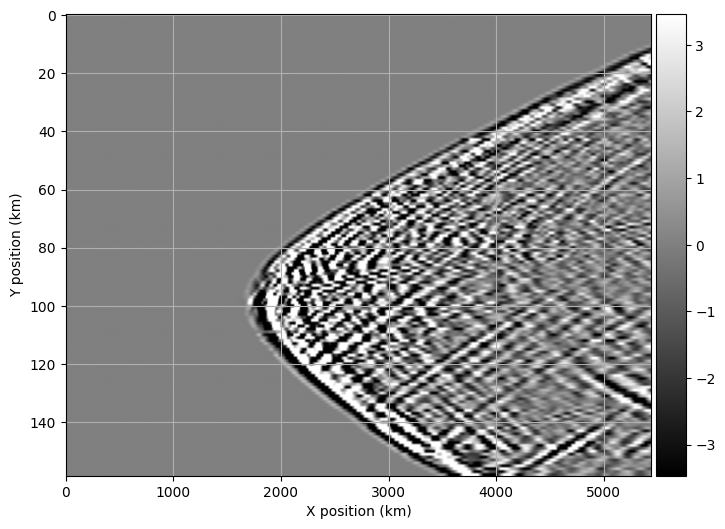

(5443, 159)


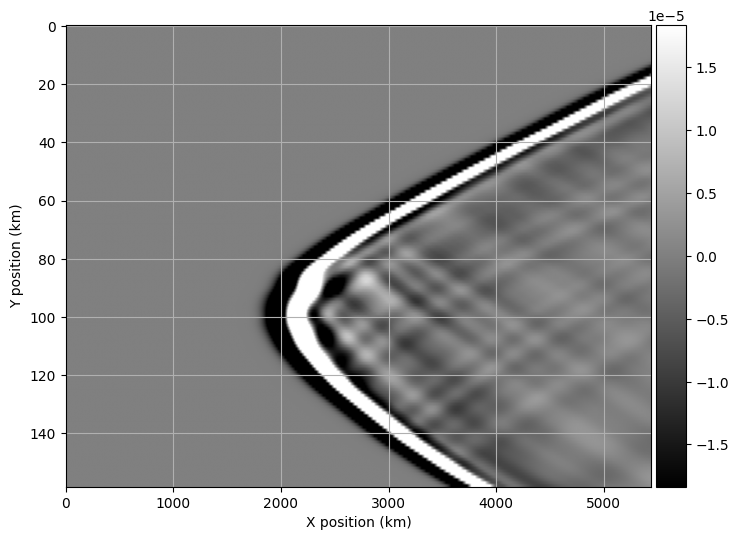

In [17]:
from examples.seismic.plotting import plot_shotrecord
plot_shotrecord(residual.data[:], t0=0, tn=50)
plot_shotrecord(d_syn.data[:], t0=0, tn=50)


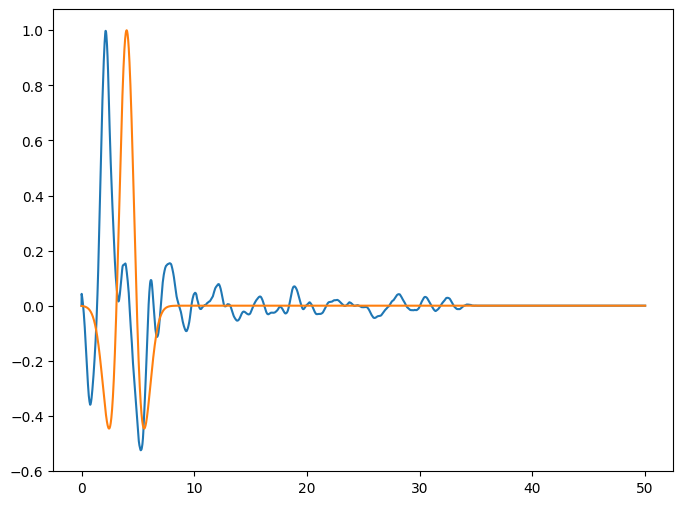

In [18]:
plt.plot(geometry.time_axis.time_values, srca.data[:]*25)
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [19]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

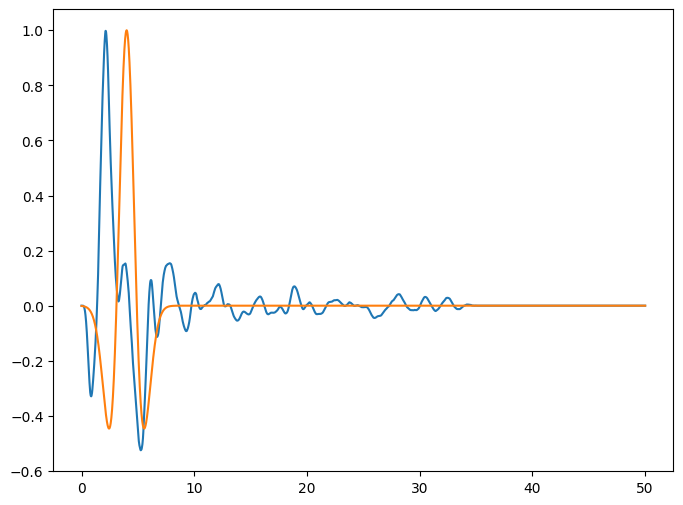

In [20]:
plt.plot(geometry.time_axis.time_values, left_taper_tukey(srca.data[:].reshape(-1)*25, alpha=0.02)[0])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [ ]:
max_iter = 5
beta = 0.001

for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0, src_type='Ricker'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = VTIWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.99), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.99))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Alpha = {alpha} Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"../adjoint_wavelets/wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"../adjoint_wavelets/wavelet_scale_{k}.npy", scale_factor)

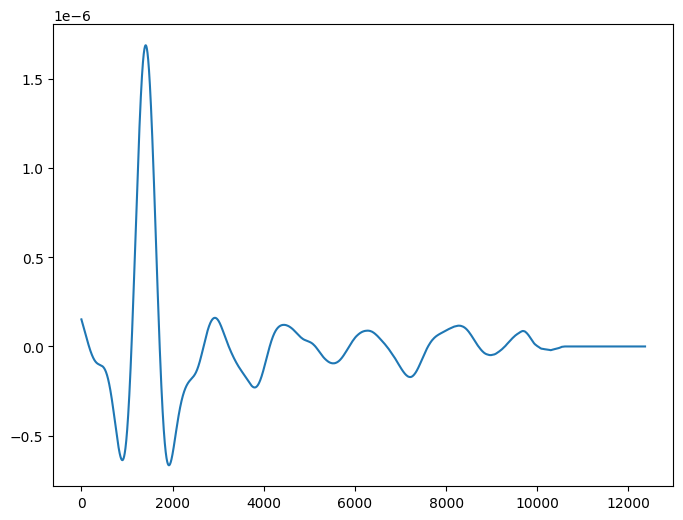

In [47]:
# plt.imshow(d_syn.data[:], aspect='auto')
# plt.imshow(d_obs.T, aspect='auto')

plt.plot(srca.data[:][1:])

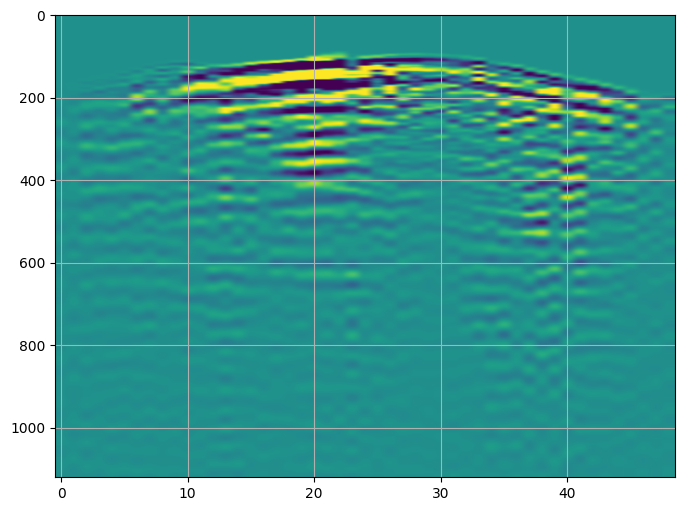

In [8]:

d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.99)

plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()

Operator `Forward` ran in 4.04 s


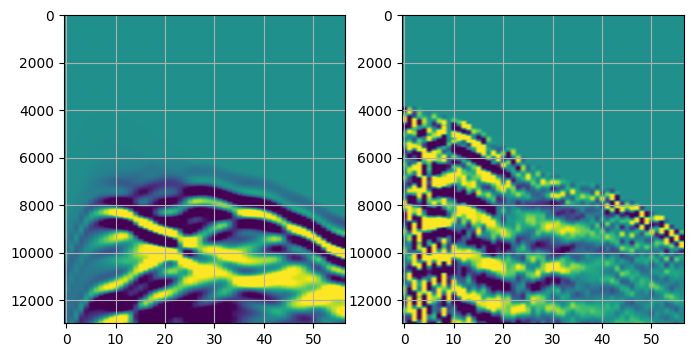

Operator `Forward` ran in 4.04 s


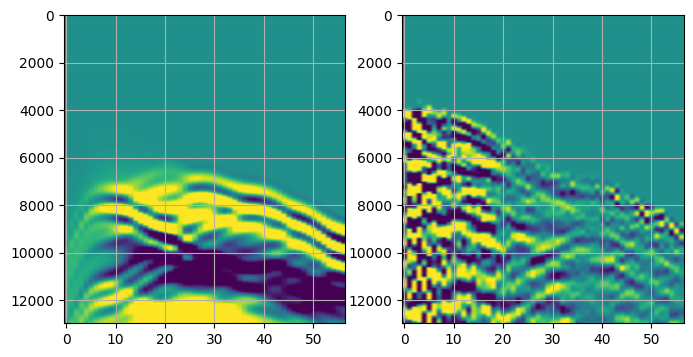

Operator `Forward` ran in 4.04 s


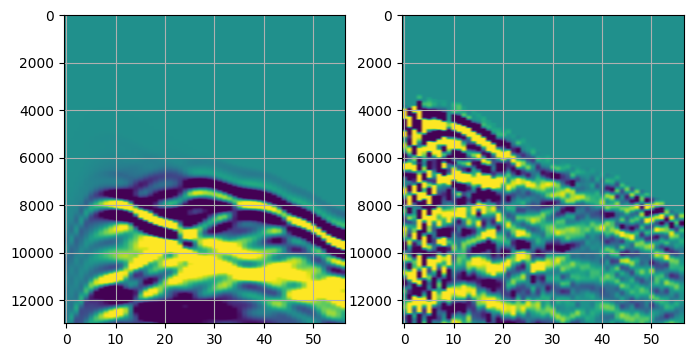

Operator `Forward` ran in 4.04 s


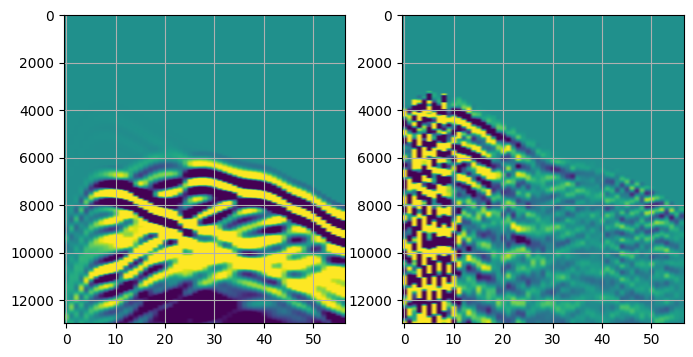

In [ ]:
N = 40
t0 = 0
tn = TMAX
for i in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[i]
    wav_data = np.load(f"Mex_wavelet_{i}_norm.npy")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=wav_data
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, save=False, rec=d_syn)
    scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
    np.save(f"Mex_wavelet_{i}_norm_scalar.npy", scale_factor)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    qa = np.quantile(d_obs, 0.95)
    axs[0].imshow(scale_factor*d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
    axs[0].grid()
    axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
    axs[1].grid()
    plt.show()
# srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

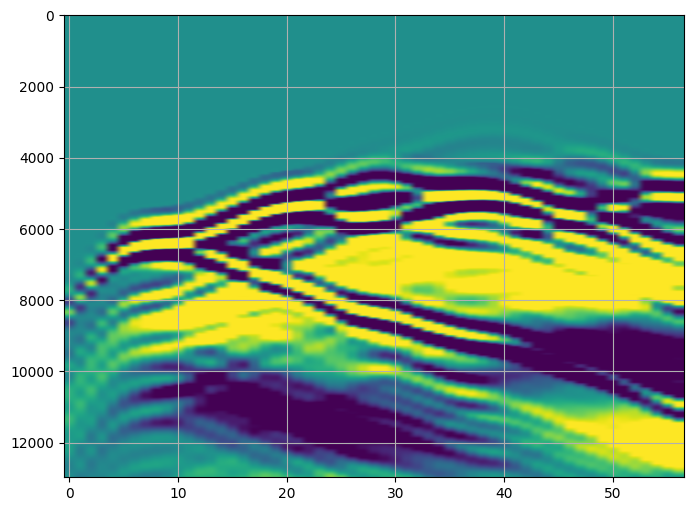

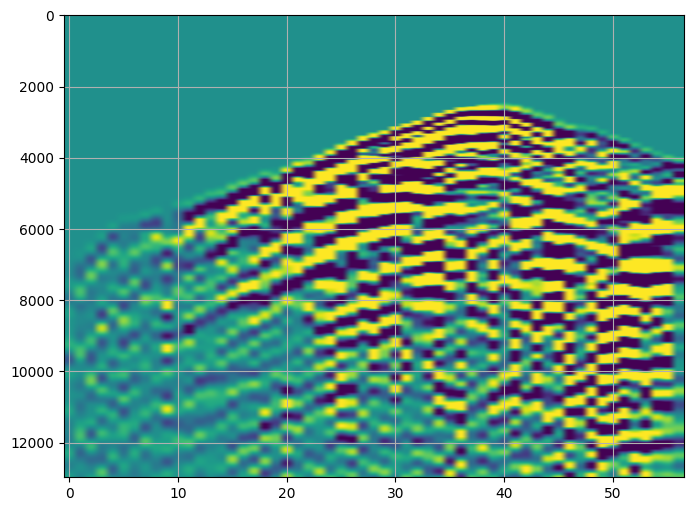

In [12]:
from matplotlib import pyplot as plt
# d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.9)
# qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.99)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()